<a href="https://colab.research.google.com/github/saraalkhaldi98/5505DL-project/blob/main/CS552J_Assessment2_Group3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS552J — Human activity classification (MSCOCO subset)


## Sections

1. **Phase A** — Data loading, stratified split, metrics  
2. **Subtask 1** — `FNN_base` vs `CNN_base`  
3. **Subtask 2** — `CNN_gen` (augmentation + regularization)  
4. **Subtask 3** — Hugging Face transfer learning, **binary** classifier (two classes)  
5. **Subtask 4** — CLIP image embeddings + small classifier  
6. **Subtask 5** — CLIP cosine similarity / text–image features  
7. **Summary** — Results table; report checklist  

Install dependencies once: `pip install -r requirements.txt`

In [2]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# --- Reproducibility (document versions in your report; run: pip freeze) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

df = pd.read_csv("cs552j_A1_dataset_image_id_url.csv")
# First column may be an unnamed index from export
if str(df.columns[0]).startswith("Unnamed") or df.columns[0] == "":
    df = df.drop(columns=[df.columns[0]])
print(df["label"].value_counts())
print("Rows:", len(df))

# Define global constants used across the notebook
IMG_SIZE = 224
NUM_CLASSES = df["label"].nunique()
LABEL2ID = {lab: i for i, lab in enumerate(sorted(df["label"].unique()))}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
print("LABEL2ID:", LABEL2ID)


Device: cuda
label
walking_running    98
sitting            95
standing           92
Name: count, dtype: int64
Rows: 285
LABEL2ID: {'sitting': 0, 'standing': 1, 'walking_running': 2}


In [3]:
# Folder where you want to save the image
save_folder = "a1_images"
os.makedirs(save_folder, exist_ok=True)

In [4]:
def download_image(image_url, save_folder, skip_existing=True):
    image_name = os.path.join(save_folder, image_url.split("/")[-1])
    if skip_existing and os.path.isfile(image_name):
        return image_name
    response = requests.get(image_url, timeout=60)
    if response.status_code == 200:
        with open(image_name, "wb") as file:
            file.write(response.content)
        print(f"Saved: {image_name}")
    else:
        print(f"Failed: {image_url}")
    return image_name

In [5]:
# Run once to download; skips files already in save_folder
for url in df.coco_url.values:
    download_image(url, save_folder, skip_existing=True)

Saved: a1_images/000000252219.jpg
Saved: a1_images/000000386912.jpg
Saved: a1_images/000000308394.jpg
Saved: a1_images/000000456496.jpg
Saved: a1_images/000000185250.jpg
Saved: a1_images/000000356427.jpg
Saved: a1_images/000000266409.jpg
Saved: a1_images/000000515579.jpg
Saved: a1_images/000000551215.jpg
Saved: a1_images/000000057597.jpg
Saved: a1_images/000000399462.jpg
Saved: a1_images/000000494869.jpg
Saved: a1_images/000000329219.jpg
Saved: a1_images/000000214720.jpg
Saved: a1_images/000000459153.jpg
Saved: a1_images/000000295713.jpg
Saved: a1_images/000000273132.jpg
Saved: a1_images/000000476415.jpg
Saved: a1_images/000000292082.jpg
Saved: a1_images/000000122046.jpg
Saved: a1_images/000000352684.jpg
Saved: a1_images/000000512836.jpg
Saved: a1_images/000000177015.jpg
Saved: a1_images/000000288042.jpg
Saved: a1_images/000000347265.jpg
Saved: a1_images/000000264535.jpg
Saved: a1_images/000000337055.jpg
Saved: a1_images/000000100624.jpg
Saved: a1_images/000000202228.jpg
Saved: a1_imag

In [6]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import os
import torch

save_folder = "a1_images"
os.makedirs(save_folder, exist_ok=True)


class ImagePathDataset(Dataset):
    """Loads images from disk; label is integer id."""

    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        y = self.labels[idx]
        img = Image.open(p).convert("RGB")  # load RGB images
        if self.transform:
            img = self.transform(img)  # apply transforms
        return img, y


def build_path_label_arrays(frame):
    paths, labels = [], []
    missing = []
    for _, row in frame.iterrows():
        fn = row["file_name"]
        p = os.path.join(save_folder, fn)
        if not os.path.isfile(p):
            missing.append(p)
            continue
        paths.append(p)
        labels.append(LABEL2ID[row["label"]])
    if missing:
        print(f"Warning: {len(missing)} files missing (run download cell).")
    return np.array(paths), np.array(labels)


paths_all, y_all = build_path_label_arrays(df)
assert len(paths_all) > 0, "No images found. Run the download cell above."

idx = np.arange(len(paths_all))

# First split: 70% train, 30% temp (for val + test)
idx_train, idx_temp, y_train_split, y_temp_split = train_test_split(
    idx, y_all, test_size=0.3, random_state=SEED, stratify=y_all
)

# Second split: 15% val, 15% test from the 30% temp set
idx_val, idx_test, y_val_split, y_test_split = train_test_split(
    idx_temp, y_temp_split, test_size=0.50, random_state=SEED, stratify=y_temp_split
)

train_paths, train_y = paths_all[idx_train], y_all[idx_train]
val_paths, val_y = paths_all[idx_val], y_all[idx_val]
test_paths, test_y = paths_all[idx_test], y_all[idx_test]

print("Train:", len(train_paths), "Val:", len(val_paths), "Test:", len(test_paths))

TRAIN_SAMPLES = len(train_paths)
class_names = [ID2LABEL[i] for i in range(NUM_CLASSES)]
print("Classes:", class_names)
print("Full training set size:", TRAIN_SAMPLES)
print("Split — train / val / test:", TRAIN_SAMPLES, len(val_paths), len(test_paths))

# Transforms for CNN_base / FNN_base (no augmentation) + normalization (x_train/255)
base_tf = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_loader_base = DataLoader(  # dataloader for training set (32 batch size)
    ImagePathDataset(train_paths, train_y, base_tf),
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader_base = DataLoader(  # dataloader for validation set (32 batch size)
    ImagePathDataset(val_paths, val_y, base_tf),
    batch_size=32,
    shuffle=False,
    num_workers=0,
)
test_loader_base = DataLoader(  # dataloader for test set (32 batch size)
    ImagePathDataset(test_paths, test_y, base_tf),
    batch_size=32,
    shuffle=False,
    num_workers=0,
)


def evaluate_classifier(model, loader, device=DEVICE):  # evaluate model on loader
    model.eval()
    ys, preds = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            pred = logits.argmax(dim=1).cpu().numpy()
            ys.append(y.numpy())
            preds.append(pred)
    y_true = np.concatenate(ys)
    y_pred = np.concatenate(preds)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return {
        "accuracy": acc,
        "macro_f1": f1,
        "confusion": confusion_matrix(y_true, y_pred),
        "report": classification_report(y_true, y_pred, target_names=[ID2LABEL[i] for i in range(NUM_CLASSES)]),
    }


def plot_confusion(cm, title):  # heatmap plot confusion matrix
    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    tick_marks = np.arange(NUM_CLASSES)
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels([ID2LABEL[i] for i in range(NUM_CLASSES)], rotation=45, ha="right")
    ax.set_yticklabels([ID2LABEL[i] for i in range(NUM_CLASSES)])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center", color="w" if cm[i, j] > cm.max() / 2 else "k")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def train_model(  # train model
    model,
    train_loader,
    val_loader,
    epochs=40,
    lr=1e-3,
    weight_decay=0.0,
    patience=8,
    model_name="model",
    scheduler=None, # Added scheduler parameter
):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)  # Adam optimizer
    crit = nn.CrossEntropyLoss()  # cross-entropy loss
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_state = None
    best_val = -1.0
    stale = 0

    for ep in range(1, epochs + 1):
        model.train()
        losses = []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)
            loss.backward()
            opt.step()
            losses.append(loss.item())
        tr = float(np.mean(losses))

        ev = evaluate_classifier(model, val_loader, DEVICE)
        va = ev["accuracy"]
        model.eval()
        vl = 0.0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                vl += crit(model(x), y).item() * x.size(0)
        vl /= len(val_loader.dataset)

        if scheduler: # Step the scheduler after validation loss is calculated
            scheduler.step(vl)

        history["train_loss"].append(tr)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)

        if va > best_val:  # update best model
            best_val = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
        if ep == 1 or ep % 5 == 0:  # print every 5 epochs
            print(f"[{model_name}] ep {ep}/{epochs} train_loss={tr:.4f} val_loss={vl:.4f} val_acc={va:.4f}")
        if stale >= patience:  # early stopping
            print(f"Early stopping at epoch {ep}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)  # load best model
    return model, history

Train: 199 Val: 43 Test: 43
Classes: ['sitting', 'standing', 'walking_running']
Full training set size: 199
Split — train / val / test: 199 43 43


## Subtask 1 — `FNN_base` vs `CNN_base`

- **FNN_base:** fully-connected network on flattened normalized pixels.  
- **CNN_base:** small convolutional network trained from scratch.  

Same train/val split and evaluation protocol.

[FNN_base] ep 1/50 train_loss=65.1740 val_loss=81.9029 val_acc=0.3256
[FNN_base] ep 5/50 train_loss=10.8600 val_loss=94.8254 val_acc=0.2093
[FNN_base] ep 10/50 train_loss=1.1146 val_loss=65.2372 val_acc=0.3256
[FNN_base] ep 15/50 train_loss=0.0871 val_loss=57.3428 val_acc=0.3256
Early stopping at epoch 19
FNN_base 0.37209302325581395 0.34327076432339587
                 precision    recall  f1-score   support

        sitting       0.42      0.71      0.53        14
       standing       0.25      0.21      0.23        14
walking_running       0.43      0.20      0.27        15

       accuracy                           0.37        43
      macro avg       0.37      0.38      0.34        43
   weighted avg       0.37      0.37      0.34        43



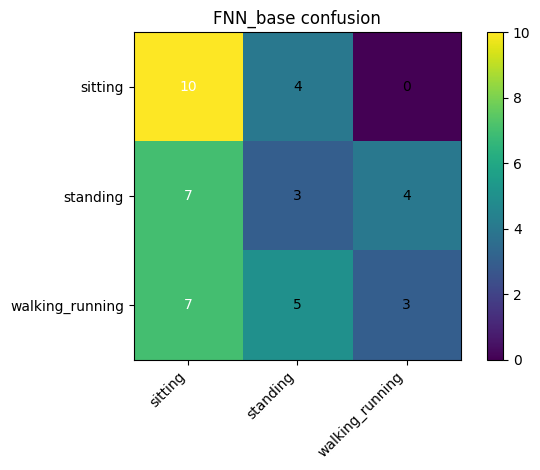

[CNN_base] ep 1/50 train_loss=1.2493 val_loss=1.1130 val_acc=0.2791
[CNN_base] ep 5/50 train_loss=0.7174 val_loss=1.3678 val_acc=0.3256
[CNN_base] ep 10/50 train_loss=0.4660 val_loss=1.5249 val_acc=0.3721
[CNN_base] ep 15/50 train_loss=0.1958 val_loss=1.8266 val_acc=0.4419
[CNN_base] ep 20/50 train_loss=0.0813 val_loss=1.8887 val_acc=0.3721
Early stopping at epoch 23
CNN_base 0.4418604651162791 0.446236559139785
                 precision    recall  f1-score   support

        sitting       0.60      0.43      0.50        14
       standing       0.41      0.50      0.45        14
walking_running       0.38      0.40      0.39        15

       accuracy                           0.44        43
      macro avg       0.46      0.44      0.45        43
   weighted avg       0.46      0.44      0.44        43



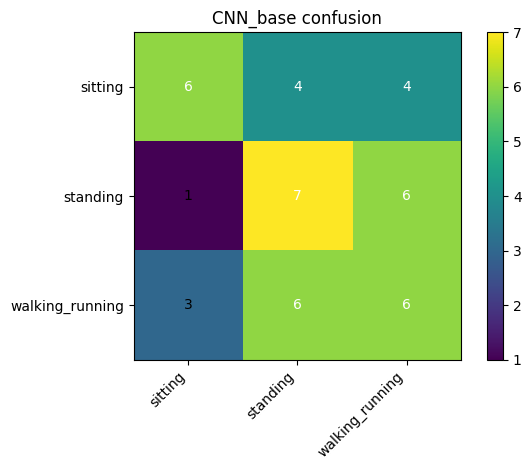

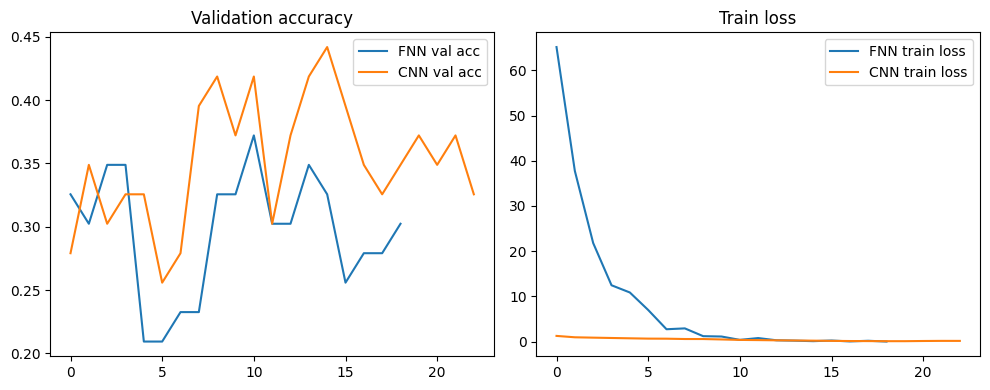

In [7]:
class FNN_base(nn.Module):
    """Fully-connected classifier on flattened image vectors."""

    def __init__(self, in_dim, num_classes=NUM_CLASSES):
        super().__init__()
        h = 512
        self.net = nn.Sequential(  # fully-connected network
            nn.Flatten(),           # flatten image
            nn.Linear(in_dim, h),   # first layer
            nn.ReLU(),              # ReLU activation
            # nn.Linear(h, h),        # second layer
            # nn.ReLU(),              # ReLU activation
            nn.Linear(h, num_classes),  # output layer
        )

    def forward(self, x):
        return self.net(x)  # forward pass


class CNN_base(nn.Module):
    """Small CNN for 3-class activity classification."""

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(  # convolutional network
            nn.Conv2d(3, 32, 3, padding=1),  # first conv layer
            nn.BatchNorm2d(32),            # batch normalization
            nn.ReLU(inplace=True),         # ReLU activation
            nn.MaxPool2d(2),               # max pooling
            nn.Conv2d(32, 64, 3, padding=1),  # second conv layer
            nn.BatchNorm2d(64),            # batch normalization
            nn.ReLU(inplace=True),         # ReLU activation
            nn.MaxPool2d(2),               # max pooling
            nn.Conv2d(64, 128, 3, padding=1),  # third conv layer
            nn.BatchNorm2d(128),           # batch normalization
            nn.ReLU(inplace=True),         # ReLU activation
            nn.MaxPool2d(2),               # max pooling
            nn.Conv2d(128, 128, 3, padding=1),  # fourth conv layer
            nn.BatchNorm2d(128),           # batch normalization
            nn.ReLU(inplace=True),         # ReLU activation
            nn.MaxPool2d(2),               # max pooling
            nn.Conv2d(128, 128, 3, padding=1),  # fifth conv layer
            nn.BatchNorm2d(128),           # batch normalization
            nn.ReLU(inplace=True),         # ReLU activation
            nn.AdaptiveAvgPool2d((4, 4)),  # adaptive average pooling
        )
        self.fc = nn.Linear(128 * 4 * 4, num_classes)  # output layer

    def forward(self, x):
        x = self.features(x)  # forward pass through convolutional network
        x = x.view(x.size(0), -1)  # flatten the output
        return self.fc(x)  # forward pass through linear layer


in_dim = 3 * IMG_SIZE * IMG_SIZE  # input dimension for fully-connected network
fnn = FNN_base(in_dim)  # create fully-connected network
fnn, hist_fnn = train_model(fnn, train_loader_base, val_loader_base, epochs=50, lr=1e-3, weight_decay=0.0, model_name="FNN_base")
res_fnn = evaluate_classifier(fnn, val_loader_base)  # evaluate model on validation set
print("FNN_base", res_fnn["accuracy"], res_fnn["macro_f1"])
print(res_fnn["report"])
plot_confusion(res_fnn["confusion"], "FNN_base confusion")

cnn = CNN_base()  # create convolutional network
cnn, hist_cnn = train_model(cnn, train_loader_base, val_loader_base, epochs=50, lr=1e-3, weight_decay=0.0, model_name="CNN_base")
res_cnn = evaluate_classifier(cnn, val_loader_base)  # evaluate model on validation set
print("CNN_base", res_cnn["accuracy"], res_cnn["macro_f1"])
print(res_cnn["report"])
plot_confusion(res_cnn["confusion"], "CNN_base confusion")  # plot confusion matrix

fig, ax = plt.subplots(1, 2, figsize=(10, 4))  # create figure with two subplots
ax[0].plot(hist_fnn["val_acc"], label="FNN val acc")  # plot validation accuracy for FNN
ax[0].plot(hist_cnn["val_acc"], label="CNN val acc")  # plot validation accuracy for CNN
ax[0].set_title("Validation accuracy")  # set title for first subplot
ax[0].legend()  # add legend to first subplot
ax[1].plot(hist_fnn["train_loss"], label="FNN train loss")  # plot training loss for FNN
ax[1].plot(hist_cnn["train_loss"], label="CNN train loss")
ax[1].set_title("Train loss")
ax[1].legend()
plt.tight_layout()
plt.show()

FNN_base Test Accuracy: 0.32558139534883723 Macro F1: 0.3081830450251503
CNN_base Test Accuracy: 0.3488372093023256 Macro F1: 0.34145021645021645


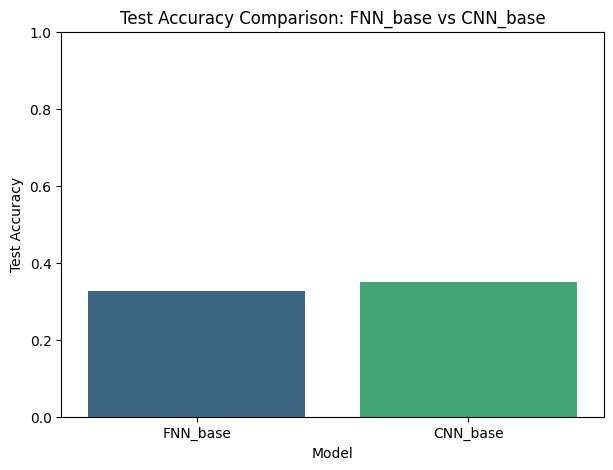

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

res_fnn_test = evaluate_classifier(fnn, test_loader_base)
res_cnn_test = evaluate_classifier(cnn, test_loader_base)

print("FNN_base Test Accuracy:", res_fnn_test["accuracy"], "Macro F1:", res_fnn_test["macro_f1"])
print("CNN_base Test Accuracy:", res_cnn_test["accuracy"], "Macro F1:", res_cnn_test["macro_f1"])

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Model': ['FNN_base', 'CNN_base'],
    'Test Accuracy': [res_fnn_test['accuracy'], res_cnn_test['accuracy']]
})

plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Test Accuracy', data=plot_df, hue='Model', palette='viridis', legend=False)
plt.title('Test Accuracy Comparison: FNN_base vs CNN_base')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy
plt.show()

## Subtask 2 — `CNN_gen` (augmented data + regularization)

Augmentation on the **training** set only; **dropout**, **weight decay**, and **early stopping** (already in `train_model`).

[CNN_gen] ep 1/60 train_loss=1.3005 val_loss=1.1054 val_acc=0.3488
[CNN_gen] ep 5/60 train_loss=1.0146 val_loss=1.1486 val_acc=0.3953
[CNN_gen] ep 10/60 train_loss=0.9144 val_loss=1.1844 val_acc=0.4186
[CNN_gen] ep 15/60 train_loss=0.8907 val_loss=1.2212 val_acc=0.3953
[CNN_gen] ep 20/60 train_loss=0.8236 val_loss=1.4062 val_acc=0.2791
Early stopping at epoch 22
CNN_gen 0.4418604651162791 0.3398268398268398
                 precision    recall  f1-score   support

        sitting       0.43      0.43      0.43        14
       standing       0.00      0.00      0.00        14
walking_running       0.45      0.87      0.59        15

       accuracy                           0.44        43
      macro avg       0.29      0.43      0.34        43
   weighted avg       0.30      0.44      0.35        43



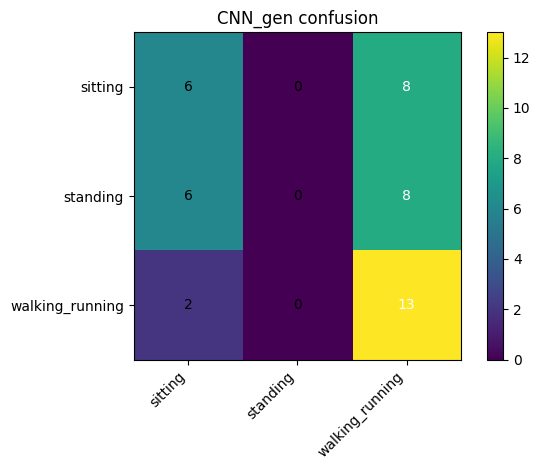

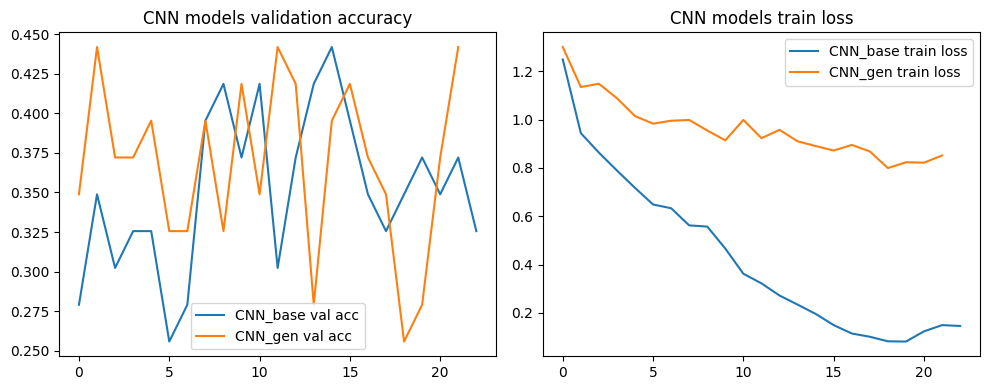

In [9]:
train_aug_tf = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_loader_gen = DataLoader(
    ImagePathDataset(train_paths, train_y, train_aug_tf),
    batch_size=32,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)


class CNN_gen(nn.Module):
    """Same backbone as CNN_base with dropout before the classifier."""

    def __init__(self, num_classes=NUM_CLASSES, p_drop=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.drop = nn.Dropout(p_drop)
        self.fc = nn.Linear(128 * 4 * 4, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        return self.fc(x)

# Original CNN_gen for comparison
cnn_gen = CNN_gen(p_drop=0.5)
cnn_gen, hist_gen = train_model(
    cnn_gen,
    train_loader_gen,
    val_loader_base,
    epochs=60,
    lr=1e-3,
    weight_decay=1e-4,
    patience=20,
    model_name="CNN_gen",
)
res_gen = evaluate_classifier(cnn_gen, val_loader_base)
print("CNN_gen", res_gen["accuracy"], res_gen["macro_f1"])
print(res_gen["report"])
plot_confusion(res_gen["confusion"], "CNN_gen confusion")


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_cnn["val_acc"], label="CNN_base val acc")
plt.plot(hist_gen["val_acc"], label="CNN_gen val acc")
plt.legend()
plt.title("CNN models validation accuracy")

plt.subplot(1, 2, 2)
plt.plot(hist_cnn["train_loss"], label="CNN_base train loss")
plt.plot(hist_gen["train_loss"], label="CNN_gen train loss")
plt.legend()
plt.title("CNN models train loss")
plt.tight_layout()
plt.show()

CNN_base Test Accuracy: 0.3488372093023256 Macro F1: 0.34145021645021645
CNN_gen Test Accuracy: 0.3488372093023256 Macro F1: 0.27499999999999997


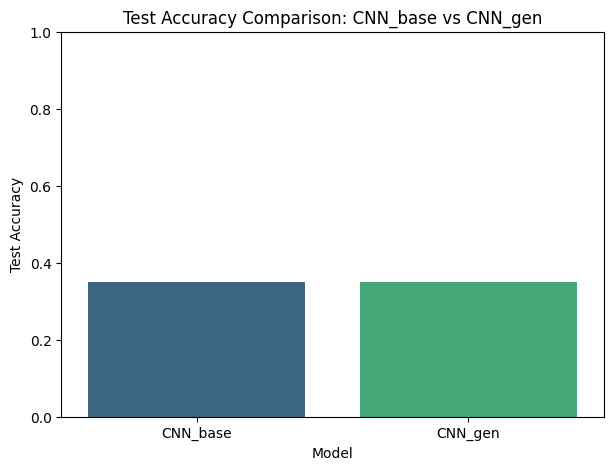

In [10]:
res_cnn_gen_test = evaluate_classifier(cnn_gen, test_loader_base)

print("CNN_base Test Accuracy:", res_cnn_test["accuracy"], "Macro F1:", res_cnn_test["macro_f1"])
print("CNN_gen Test Accuracy:", res_cnn_gen_test["accuracy"], "Macro F1:", res_cnn_gen_test["macro_f1"])

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Model': ['CNN_base', 'CNN_gen'],
    'Test Accuracy': [res_cnn_test['accuracy'], res_cnn_gen_test['accuracy']]
})

plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Test Accuracy', data=plot_df, hue='Model', palette='viridis', legend=False)
plt.title('Test Accuracy Comparison: CNN_base vs CNN_gen')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy
plt.show()

### CNN_base with Augmentation (`CNN_base_aug`)

Now, let's train the `CNN_base` architecture with the augmented training data (`train_loader_gen`) and some regularization (`weight_decay`) to see its impact on performance.

[CNN_base_aug] ep 1/60 train_loss=1.1968 val_loss=1.1262 val_acc=0.2791
[CNN_base_aug] ep 5/60 train_loss=0.9425 val_loss=1.2643 val_acc=0.2791
[CNN_base_aug] ep 10/60 train_loss=0.8276 val_loss=1.1772 val_acc=0.3953
[CNN_base_aug] ep 15/60 train_loss=0.7338 val_loss=1.3309 val_acc=0.3721
[CNN_base_aug] ep 20/60 train_loss=0.6808 val_loss=1.4978 val_acc=0.3256
[CNN_base_aug] ep 25/60 train_loss=0.6270 val_loss=1.3248 val_acc=0.4419
Early stopping at epoch 27
CNN_base_aug 0.4883720930232558 0.4836718438868976
                 precision    recall  f1-score   support

        sitting       0.53      0.64      0.58        14
       standing       0.50      0.50      0.50        14
walking_running       0.42      0.33      0.37        15

       accuracy                           0.49        43
      macro avg       0.48      0.49      0.48        43
   weighted avg       0.48      0.49      0.48        43



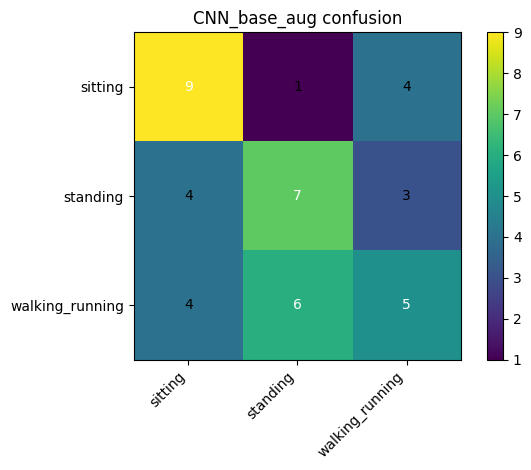

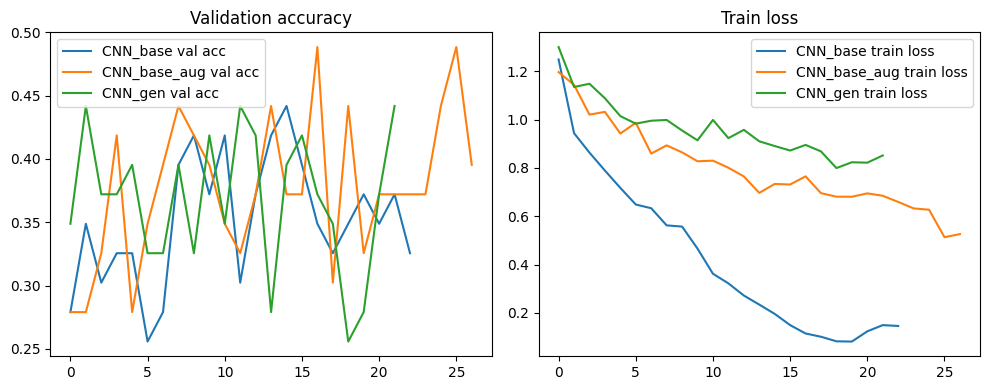

In [11]:
cnn_base_aug = CNN_base() # Re-instantiate CNN_base
cnn_base_aug, hist_base_aug = train_model(
    cnn_base_aug,
    train_loader_gen, # Use the augmented training loader
    val_loader_base,
    epochs=60,
    lr=1e-3,
    weight_decay=1e-5, # Add weight decay for regularization
    patience=10,
    model_name="CNN_base_aug",
)
res_base_aug = evaluate_classifier(cnn_base_aug, val_loader_base) # Evaluate model on validation set
print("CNN_base_aug", res_base_aug["accuracy"], res_base_aug["macro_f1"])
print(res_base_aug["report"])
plot_confusion(res_base_aug["confusion"], "CNN_base_aug confusion") # Plot confusion matrix

# Plot validation accuracy and training loss comparison
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist_cnn["val_acc"], label="CNN_base val acc")
plt.plot(hist_base_aug["val_acc"], label="CNN_base_aug val acc")
plt.plot(hist_gen["val_acc"], label="CNN_gen val acc")
plt.legend()
plt.title("Validation accuracy")

plt.subplot(1, 2, 2)
plt.plot(hist_cnn["train_loss"], label="CNN_base train loss")
plt.plot(hist_base_aug["train_loss"], label="CNN_base_aug train loss")
plt.plot(hist_gen["train_loss"], label="CNN_gen train loss")
plt.legend()
plt.title("Train loss")
plt.tight_layout()
plt.show()

CNN_base Test Accuracy: 0.3488372093023256 Macro F1: 0.34145021645021645
CNN_base_aug Test Accuracy: 0.3953488372093023 Macro F1: 0.371441424073003
CNN_gen Test Accuracy: 0.3488372093023256 Macro F1: 0.27499999999999997


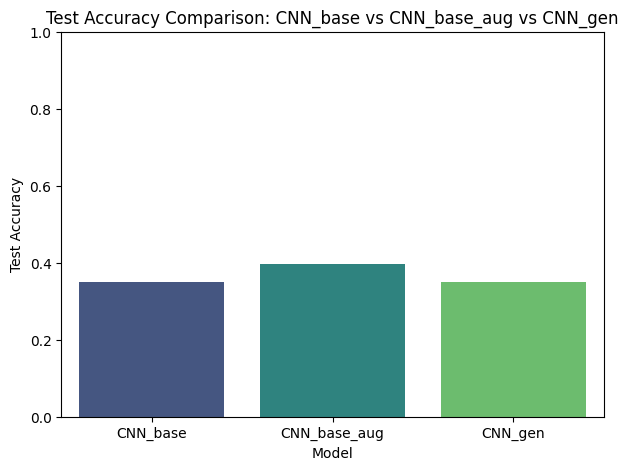

In [16]:
res_cnn_aug_test = evaluate_classifier(cnn_base_aug, test_loader_base)

print("CNN_base Test Accuracy:", res_cnn_test["accuracy"], "Macro F1:", res_cnn_test["macro_f1"])
print("CNN_base_aug Test Accuracy:", res_cnn_aug_test["accuracy"], "Macro F1:", res_cnn_aug_test["macro_f1"])
print("CNN_gen Test Accuracy:", res_cnn_gen_test["accuracy"], "Macro F1:", res_cnn_gen_test["macro_f1"])

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Model': ['CNN_base', 'CNN_base_aug', 'CNN_gen'],
    'Test Accuracy': [res_cnn_test['accuracy'], res_cnn_aug_test['accuracy'], res_cnn_gen_test['accuracy']]
})

plt.figure(figsize=(7, 5))
sns.barplot(x='Model', y='Test Accuracy', data=plot_df, hue='Model', palette='viridis', legend=False)
plt.title('Test Accuracy Comparison: CNN_base vs CNN_base_aug vs CNN_gen')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy
plt.show()

## Generalization Gap Analysis

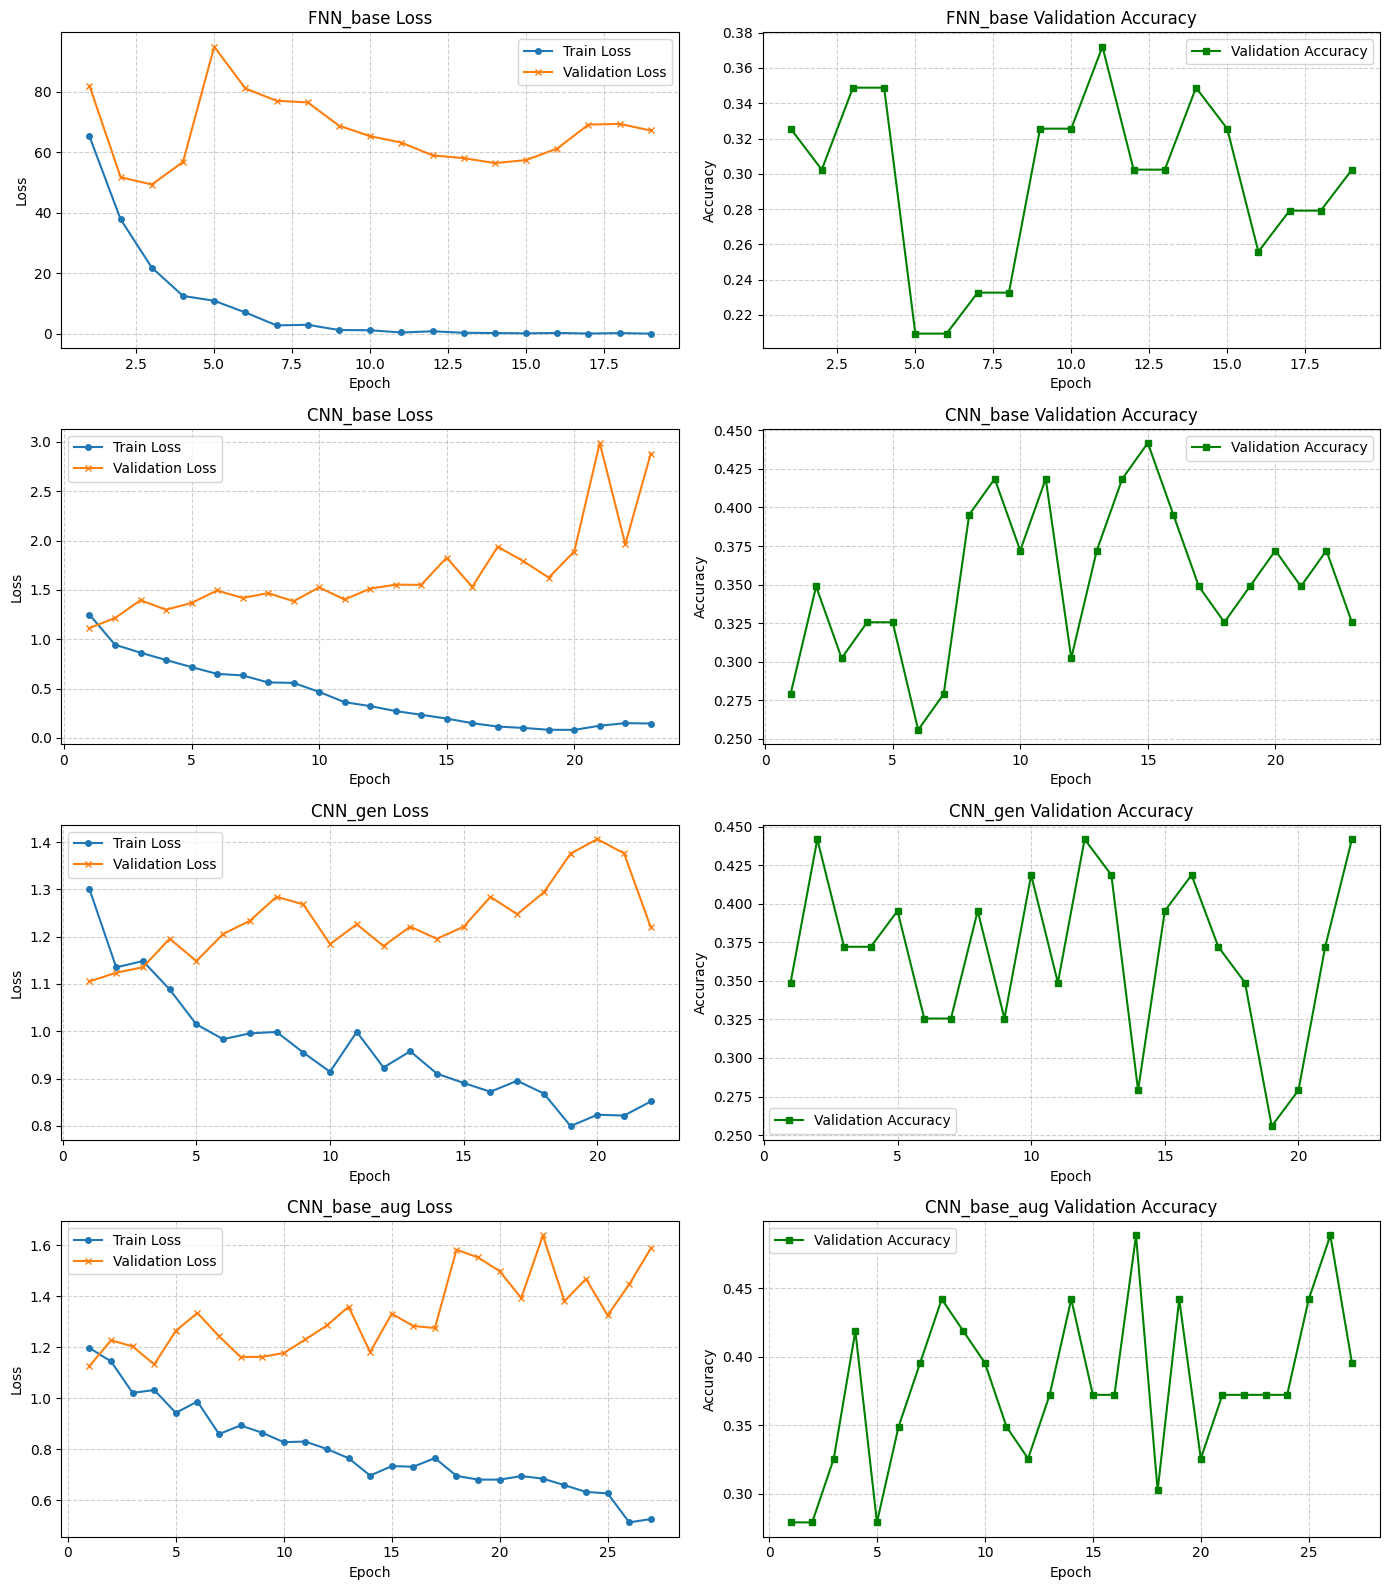


--- Final Metrics ---
Model           Train Loss      Val Loss        Val Accuracy   
FNN_base        0.0000          67.1282         0.3023         
CNN_base        0.1458          2.8816          0.3256         
CNN_gen         0.8516          1.2195          0.4419         
CNN_base_aug    0.5262          1.5876          0.3953         

--- Final Generalization Gap (Validation Loss - Train Loss) ---
FNN_base: 67.1282
CNN_base: 2.7359
CNN_gen: 0.3679
CNN_base_aug: 1.0614


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine histories into a dictionary for easier iteration
model_histories = {
    "FNN_base": hist_fnn,
    "CNN_base": hist_cnn,
    "CNN_gen": hist_gen,
    "CNN_base_aug": hist_base_aug,
}

# Determine the number of models
num_models = len(model_histories)

# Create a figure with 2 columns (one for loss, one for accuracy) and num_models rows
fig, axes = plt.subplots(num_models, 2, figsize=(14, num_models * 4)) # Adjust figsize dynamically

for i, (model_name, history) in enumerate(model_histories.items()):
    # Plot Loss (Train and Validation)
    ax_loss = axes[i, 0] # Get the first subplot in the current row
    epochs = range(1, len(history['train_loss']) + 1)
    ax_loss.plot(epochs, history['train_loss'], label='Train Loss', marker='o', markersize=4)
    ax_loss.plot(epochs, history['val_loss'], label='Validation Loss', marker='x', markersize=4)
    ax_loss.set_title(f'{model_name} Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, linestyle='--', alpha=0.6)

    # Plot Validation Accuracy
    ax_acc = axes[i, 1] # Get the second subplot in the current row
    ax_acc.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='s', markersize=4, color='green')
    ax_acc.set_title(f'{model_name} Validation Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Calculate and print final metrics
print("\n--- Final Metrics ---")
print("{:<15} {:<15} {:<15} {:<15}".format("Model", "Train Loss", "Val Loss", "Val Accuracy"))
for model_name, history in model_histories.items():
    final_train_loss = history['train_loss'][-1]
    final_val_loss = history['val_loss'][-1]
    final_val_acc = history['val_acc'][-1]
    print(f"{model_name:<15} {final_train_loss:<15.4f} {final_val_loss:<15.4f} {final_val_acc:<15.4f}")

print("\n--- Final Generalization Gap (Validation Loss - Train Loss) ---")
for model_name, history in model_histories.items():
    final_train_loss = history['train_loss'][-1]
    final_val_loss = history['val_loss'][-1]
    gap = final_val_loss - final_train_loss
    print(f'{model_name}: {gap:.4f}')

## Subtask 3 — Transfer learning (Hugging Face), binary classifier

We use **two** action classes (configurable): default **`sitting` vs `standing`**.  
A small pretrained model (`microsoft/resnet-18`) is fine-tuned with a **binary** head.

## Subtask 4 — CLIP image embeddings + small classifier

Frozen **CLIP** image encoder; train a **linear** (or MLP) head on top of L2-normalized embeddings.

## Subtask 5 — CLIP text–image similarity features

Encode **prompts** for each class, take **cosine similarity** (dot product on L2-normalized vectors) between image and text embeddings → **logits** for argmax.  
Optionally compare to a small **linear classifier** on the concatenation `[image_emb || cosine_scores]`.

## Summary — results table (test set)


In [ ]:
summary = pd.DataFrame(
    [
        ["FNN_base", res_fnn["accuracy"], res_fnn["macro_f1"]],
        ["CNN_base", res_cnn["accuracy"], res_cnn["macro_f1"]],
        ["CNN_gen", res_gen["accuracy"], res_gen["macro_f1"]],
        ["CNN_base_aug", res_base_aug["accuracy"], res_base_aug["macro_f1"]], # Add new model results
        [f"HF binary ({BINARY_CLASSES[0]} vs {BINARY_CLASSES[1]})", hf_bin_acc, hf_bin_f1],
        ["CLIP image emb + MLP (Subtask 4)", res_clip["accuracy"], res_clip["macro_f1"]],
        ["CLIP zero-shot cosine (Subtask 5)", acc_zs, f1_zs],
        ["CLIP hybrid image+cosine (Subtask 5)", acc_hyb, f1_hyb],
    ],
    columns=["Model", "val_accuracy", "val_macro_f1"],
)
display(summary)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='val_accuracy', data=summary, hue='Model', palette='viridis', legend=False)
plt.title('Validation Accuracy Comparison Across All Models')
plt.xlabel('Model')
plt.ylabel('Validation Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # Set y-axis limits from 0 to 1 for accuracy
plt.tight_layout()
plt.show()

## Report checklist

1.  **Reproducibility** — `SEED`, train/val split ratio, augmentations, model names (`CNN_base` / `CNN_gen` / `microsoft/resnet-18` / `openai/clip-vit-base-patch32`), optimizer settings.  
3. **Environment** — run `pip freeze > requirements-frozen.txt` after `pip install -r requirements.txt` and attach or quote versions.  
4. **Figures** — learning curves (Subtask 1–5), confusion matrices, summary tables above.  
5. **Analysis** — compare FNN vs CNN; effect of augmentation/regularization; why CLIP helps or fails on ambiguous poses; limitation of small data.

---

## Bonus (optional) — quick error analysis

Inspect **confusion pairs** (e.g. sitting vs standing) without extra libraries.

In [ ]:
# cm = res_gen["confusion"]
# print("CNN_gen confusion matrix (rows=true, cols=pred):\n", cm)
# off_diag = []
# for i in range(NUM_CLASSES):
#     for j in range(NUM_CLASSES):
#         if i != j and cm[i, j] > 0:
#             off_diag.append((ID2LABEL[i], ID2LABEL[j], int(cm[i, j])))
# off_diag.sort(key=lambda x: -x[2])
# print("Top misclassification pairs:", off_diag[:6])